# Prática de Laboratório Local: Modelo Orientado a Documentos

## Objetivo da Prática

Explorar o funcionamento de um banco de dados orientado a documentos utilizando uma ferramenta local (MongoDB ou TinyDB) para armazenar e consultar dados em formato JSON. O objetivo é entender como os dados são organizados, armazenados e recuperados em sistemas orientados a documentos.

### Recursos Necessários

- Ferramentas:
    - Python instalado no computador.
    - Bibliotecas Python: pymongo (para MongoDB) ou tinydb (para uma solução leve).
    - MongoDB Community Server (opcional, se quiser usar MongoDB localmente).
- Conjunto de Dados:
    - Um arquivo JSON com dados simulados (ex.: perfis de usuários, produtos de e-commerce).
    - Exemplo: Kaggle Dataset - E-commerce ou qualquer conjunto de dados JSON.

Parte 1: Preparação do Ambiente

    Instalar as bibliotecas necessárias:
    Abra o terminal e execute os seguintes comandos:

In [1]:

pip install pymongo tinydb

   ---------------------------------------- 0.0/959.2 kB ? eta -:--:--
   ---------------------------------------- 959.2/959.2 kB 16.3 MB/s  0:00:00

   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   ------------- -------------------------- 1/3 [dnspython]
   -------------------------- ------------- 2/3 [pymongo]
   -------------------------- ------------- 2/3 [pymongo]
   -------------------------- ------------- 2/3 [pymongo]
   -------------

### Baixar ou gerar o conjunto de dados:

Baixe um arquivo JSON grande (ex.: perfis de usuários ou produtos) ou gere um conjunto de dados sintético usando Python:

In [1]:
import json

# Gerar dados sintéticos
data = [
    {
        "IDUsuario": i,
        "Nome": f"Usuario_{i}",
        "Endereco": {
            "Rua": f"Rua_{i % 10}",
            "Numero": i * 10,
            "Cidade": "São Paulo" if i % 2 == 0 else "Rio de Janeiro"
        },
        "Pedidos": [
            {"IDPedido": j, "Valor": (i + j) * 10}
            for j in range(1, 4)
        ]
    }
    for i in range(1, 11)
]

# Salvar como JSON
with open("dados_usuarios.json", "w") as file:
    json.dump(data, file, indent=4)

Configurar o MongoDB (opcional):

    Instale o MongoDB Community Server e inicie o serviço.
    Conecte-se ao MongoDB localmente usando Python:

In [5]:
from pymongo import MongoClient

# Conectar ao MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["meu_banco"]
collection = db["usuarios"]

Parte 2: Armazenamento e Consulta de Dados

    Inserir dados no banco de documentos:
        Usando MongoDB:

In [6]:
# Ler o arquivo JSON
with open("dados_usuarios.json", "r") as file:
    usuarios = json.load(file)

# Inserir dados na coleção
collection.insert_many(usuarios)

InsertManyResult([ObjectId('69c48b034d04c4c112cd6039'), ObjectId('69c48b034d04c4c112cd603a'), ObjectId('69c48b034d04c4c112cd603b'), ObjectId('69c48b034d04c4c112cd603c'), ObjectId('69c48b034d04c4c112cd603d'), ObjectId('69c48b034d04c4c112cd603e'), ObjectId('69c48b034d04c4c112cd603f'), ObjectId('69c48b034d04c4c112cd6040'), ObjectId('69c48b034d04c4c112cd6041'), ObjectId('69c48b034d04c4c112cd6042')], acknowledged=True)

Usando TinyDB (alternativa leve):

In [8]:
from tinydb import TinyDB, Query

# Criar ou abrir o banco de dados
db = TinyDB("usuarios_tinydb.json")

# Inserir dados
with open("dados_usuarios.json", "r") as file:
    usuarios = json.load(file)
db.insert_multiple(usuarios)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Consultar dados no banco de documentos:

    Usando MongoDB:

In [7]:
# Consultar todos os usuários de São Paulo
usuarios_sp = collection.find({"Endereco.Cidade": "São Paulo"})
for usuario in usuarios_sp:
    print(usuario)

# Consultar pedidos de um usuário específico
usuario_pedidos = collection.find_one({"IDUsuario": 1}, {"_id": 0, "Pedidos": 1})
print(usuario_pedidos)

{'_id': ObjectId('69c48b034d04c4c112cd603a'), 'IDUsuario': 2, 'Nome': 'Usuario_2', 'Endereco': {'Rua': 'Rua_2', 'Numero': 20, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 30}, {'IDPedido': 2, 'Valor': 40}, {'IDPedido': 3, 'Valor': 50}]}
{'_id': ObjectId('69c48b034d04c4c112cd603c'), 'IDUsuario': 4, 'Nome': 'Usuario_4', 'Endereco': {'Rua': 'Rua_4', 'Numero': 40, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 50}, {'IDPedido': 2, 'Valor': 60}, {'IDPedido': 3, 'Valor': 70}]}
{'_id': ObjectId('69c48b034d04c4c112cd603e'), 'IDUsuario': 6, 'Nome': 'Usuario_6', 'Endereco': {'Rua': 'Rua_6', 'Numero': 60, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 70}, {'IDPedido': 2, 'Valor': 80}, {'IDPedido': 3, 'Valor': 90}]}
{'_id': ObjectId('69c48b034d04c4c112cd6040'), 'IDUsuario': 8, 'Nome': 'Usuario_8', 'Endereco': {'Rua': 'Rua_8', 'Numero': 80, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 90}, {'IDPedido': 2, 'Valor': 100}, {'IDPedido': 3, 'V

Usando TinyDB:

In [9]:
# Definir a consulta
Usuario = Query()

# Consultar todos os usuários de São Paulo
usuarios_sp = db.search(Usuario.Endereco.Cidade == "São Paulo")
print(usuarios_sp)

# Consultar pedidos de um usuário específico
usuario_pedidos = db.search(Usuario.IDUsuario == 1)
print(usuario_pedidos[0]["Pedidos"])

[{'IDUsuario': 2, 'Nome': 'Usuario_2', 'Endereco': {'Rua': 'Rua_2', 'Numero': 20, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 30}, {'IDPedido': 2, 'Valor': 40}, {'IDPedido': 3, 'Valor': 50}]}, {'IDUsuario': 4, 'Nome': 'Usuario_4', 'Endereco': {'Rua': 'Rua_4', 'Numero': 40, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 50}, {'IDPedido': 2, 'Valor': 60}, {'IDPedido': 3, 'Valor': 70}]}, {'IDUsuario': 6, 'Nome': 'Usuario_6', 'Endereco': {'Rua': 'Rua_6', 'Numero': 60, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 70}, {'IDPedido': 2, 'Valor': 80}, {'IDPedido': 3, 'Valor': 90}]}, {'IDUsuario': 8, 'Nome': 'Usuario_8', 'Endereco': {'Rua': 'Rua_8', 'Numero': 80, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 90}, {'IDPedido': 2, 'Valor': 100}, {'IDPedido': 3, 'Valor': 110}]}, {'IDUsuario': 10, 'Nome': 'Usuario_10', 'Endereco': {'Rua': 'Rua_0', 'Numero': 100, 'Cidade': 'São Paulo'}, 'Pedidos': [{'IDPedido': 1, 'Valor': 110}, {'IDPedido

Atualizar e excluir dados:

    Usando MongoDB:

In [10]:
# Atualizar o número de um endereço
collection.update_one({"IDUsuario": 1}, {"$set": {"Endereco.Numero": 999}})

# Excluir um usuário
collection.delete_one({"IDUsuario": 10})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

Usando TinyDB:

In [11]:
# Atualizar o número de um endereço
db.update({"Endereco.Numero": 999}, Usuario.IDUsuario == 1)

# Excluir um usuário
db.remove(Usuario.IDUsuario == 10)

[10]

Parte 3: Análise dos Resultados

    Discussão em sala:
        Quais são as vantagens de usar um banco de dados orientado a documentos em comparação com um banco relacional?
        Em quais cenários o modelo orientado a documentos é mais adequado?
    Visualização dos dados:
        Use uma ferramenta gráfica (ex.: Matplotlib ou Seaborn) para visualizar os resultados das consultas:

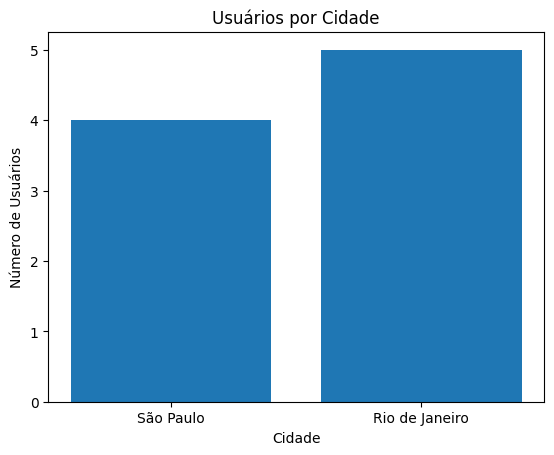

In [12]:
import matplotlib.pyplot as plt

# Contagem de usuários por cidade
cidades = ["São Paulo", "Rio de Janeiro"]
contagem = [len(db.search(Usuario.Endereco.Cidade == cidade)) for cidade in cidades]

plt.bar(cidades, contagem)
plt.title("Usuários por Cidade")
plt.xlabel("Cidade")
plt.ylabel("Número de Usuários")
plt.show()

Conclusão

    Resumo:
        Bancos de dados orientados a documentos, como o Amazon DynamoDB, utilizam formatos flexíveis como JSON para armazenar dados.
        A estrutura hierárquica e a ausência de esquemas fixos facilitam o armazenamento de dados semi-estruturados.
    Reflexão:
        Por que o modelo orientado a documentos é popular em aplicações modernas, como IoT e sistemas de conteúdo?